In [1]:
# 参考 https://inzkyk.xyz/kalman_filter/
%pip install filterpy
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


# g-h filter 
## あとでまとめ記入

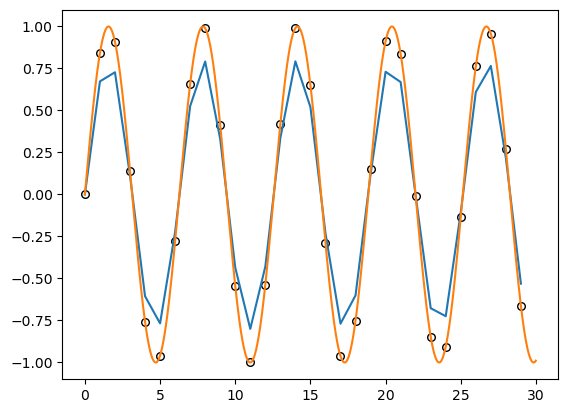

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.gh import GHFilter
from numpy.random import randn


def gen_data(x0, dx, count, noise_factor):
    return [x0 + dx*i + randn()*noise_factor for i in range(count)]

def sinx(a, x0, dx, count, noise_factor):
    return np.sin(np.array([x0 + dx*i + randn()*noise_factor for i in range(count)]))

data = sinx(3, 0, 1,30, 0)
data = np.array(data)
f = GHFilter(x=0., dx=0., dt=1., g=.8, h=.2)
res_x, res_dx = f.update(data)
plt.plot(np.arange(len(res_x)), res_x)
plt.plot(np.arange(0, len(res_x), 0.01), np.sin(np.arange(0, len(res_x), 0.01)))
plt.scatter(np.arange(len(res_x)), data, s=30, c="w", ec="black")

# 離散ベイズフィルタ
事前確率分布<br>
事前に得た情報の事前分布

確率分布<br>
起こりうるすべての事象の確率（合計は１）

頻度主義的統計学<br>
頻度に基づいた確率

ベイズ統計学<br>
一つの事象に関する信念（知識の強さの指標）

$事後分布 = \frac{尤度\times 事前分布}{正規化係数}$
イメージは，<br>
$更新された知識 = ||新しい知識の尤度 \times 事前の知識||$


<BarContainer object of 10 artists>

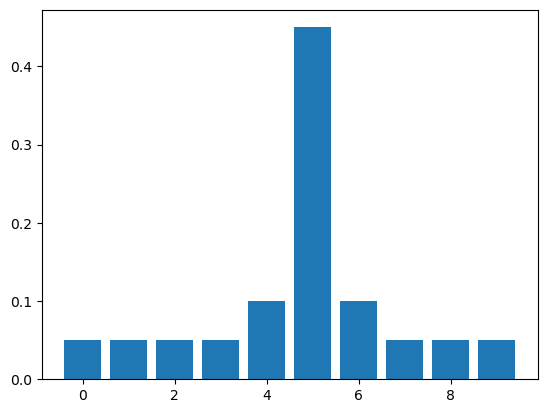

In [3]:
from filterpy.discrete_bayes import predict
import matplotlib.pyplot as plt
import numpy as np

# 畳み込み
belief = [.05, .05, .05, .05, .55, .05, .05, .05, .05, .05]
prior = predict(belief, offset=1, kernel=[.1, .8, .1])
plt.bar(np.arange(len(prior)), prior)

In [4]:
# 離散ベイズフィルタ
def normalize(p):
    return p / sum(p)

def update(likelihood, prior):
    return normalize(likelihood * prior)

prior      = normalize(np.array([4, 2, 0, 7, 2, 12, 35, 20, 3, 2]))
likelihood = normalize(np.array([3, 4, 1, 4, 2, 38, 20, 18, 1, 16]))
posterior  = update(likelihood, prior)

## 分散
平均の差の二乗<br>
二乗をしないで足し合わせると，X=[3,−3,3,−3]は明らかに分散しているが，0になってしまう。絶対値を取るだけだと， Y=[6,−2,−3,1]のほうが明らかに分散しているがどちらも3になってしまう．<br>
大体，分散は二乗の値の方が良さそうっていう感じで考えられたものらしい<br>
そのためか，<br>
X = [1, -1, 1, -2, -1, 2, 1, 2, -1, 1, -1, 2, 1, -2, 100]
外れ値を入れた X の分散 = 621.45
外れ値を除いた X の分散 =   2.03

## 標準偏差
分散の平方根<br>
平均+-(1$\sigma$, 2$\sigma$, 3$\sigma$)の間で(68, 95, 99.7)%のデータが存在する

## ベイズの定理
直感的なイメージ<br>
センサー情報から天気予報（雨）の確率を計算したい$p(x_i|z)$<br>
雨が降った時のセンサー情報（知識）はある$p(z|x_i)$<br>
ベイズの定理を使えば，$p(x_i|z)$を$p(z|x_i)$で表せるので，天気予報（雨）の確率$p(x_i|z)$が計算できるようになる<br>

ベイズの定理: $p(x_i|z) = \frac{p(z|x_i)p(x_i)}{p(z)}$

## 全確率の定理
時刻$t$にいる確率は，一時刻前にある状態にいる確率とその状態から今の状態に遷移する確率の乗算を全状態に対してした和になる<br>
$P(X^t_i) = \sum_j P(X^{t-1}_j)P(x_i|x_j)$

## 歪度
正規分布が対称性を持たない度合い

## 尖度
正規分布と比べたときに裾が短かったり、長かったり、厚かったり、薄かったりすることを表す指標

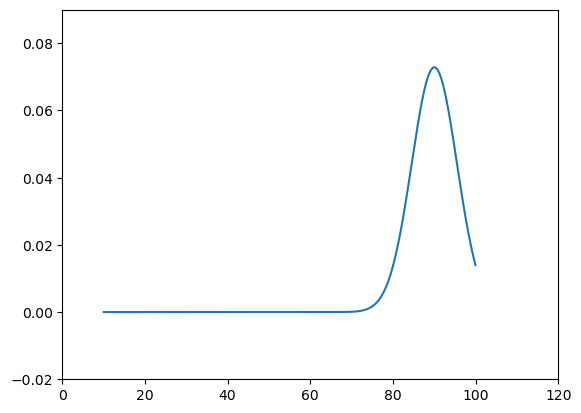

In [5]:
# gaussian
from scipy.stats import norm
from filterpy.stats import gaussian
xs = np.arange(10, 100, 0.05)
ys = [gaussian(x, 90, 30) for x in xs]
plt.plot(xs, ys, label='var=0.2')
plt.xlim(0, 120)
plt.ylim(-0.02, 0.09);

平均: 5.88 分散: 1.24


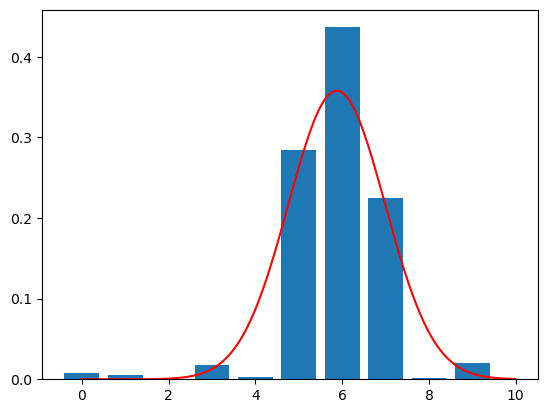

In [6]:
# 離散ベイズフィルタとガウシアンのプロット
# 離散ベイズってガウシアンで近似できそうだね

xs = np.arange(0, 10, .01)

def mean_var(p):
    x = np.arange(len(p))
    mean = np.sum(p * x,dtype=float)
    var = np.sum((x - mean)**2 * p)
    return mean, var

mean, var = mean_var(posterior)
plt.bar(np.arange(len(posterior)), posterior)
plt.plot(xs, gaussian(xs, mean, var, normed=False), c='r');
print('平均: %.2f' % mean, '分散: %.2f' % var)


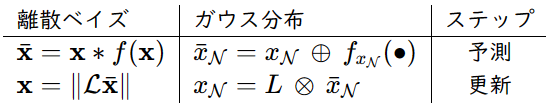
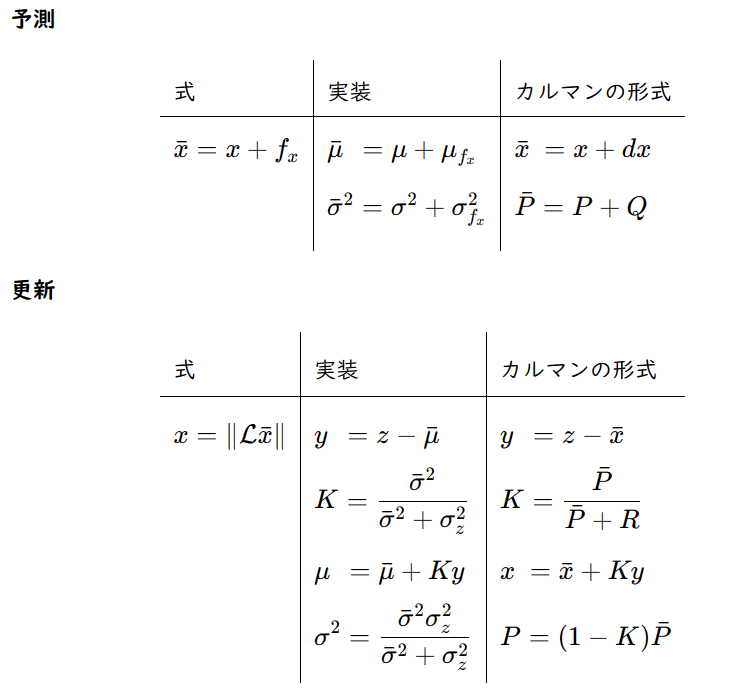
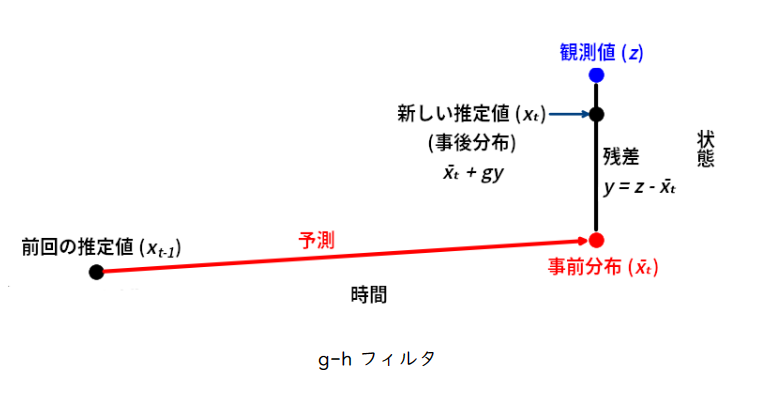

In [7]:
from collections import namedtuple
import matplotlib.pyplot as plt

gaussian = namedtuple('Gaussian', ['mean', 'var'])
gaussian.__repr__ = lambda s: '𝒩(μ={:.3f}, 𝜎²={:.3f})'.format(s[0], s[1])
g1 = gaussian(3.4, 10.1)
g2 = gaussian(mean=4.5, var=0.2**2)
print(g1)
print(g2)

# 単純な足し算で平均と分散を更新
def predict(pos, movement):
    return gaussian(pos.mean + movement.mean, pos.var + movement.var)

# ガウス分布同士の積
def gaussian_multiply(g1, g2):
    mean = (g1.var * g2.mean + g2.var * g1.mean) / (g1.var + g2.var)
    variance = (g1.var * g2.var) / (g1.var + g2.var)
    return gaussian(mean, variance)

# 前の更新式
def update_old(likelihood, prior):
    posterior = likelihood * prior
    return normalize(posterior)

# ガウシアンで更新
def update(prior, likelihood):
    posterior = gaussian_multiply(likelihood, prior)
    return posterior

predicted_pos = gaussian(10., .2**2)
measured_pos = gaussian(11., .1**2)
estimated_pos = update(predicted_pos, measured_pos)

𝒩(μ=3.400, 𝜎²=10.100)
𝒩(μ=4.500, 𝜎²=0.040)


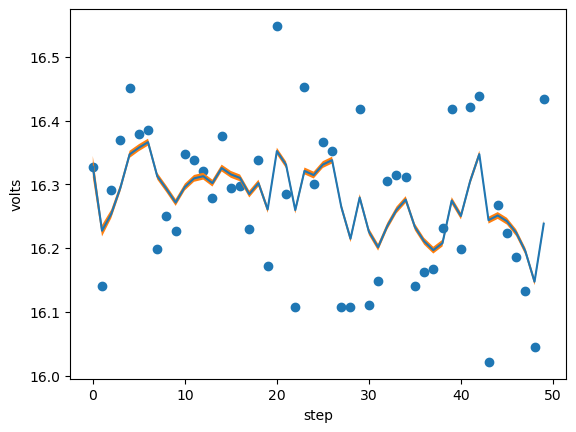

Variance converges to 0.005


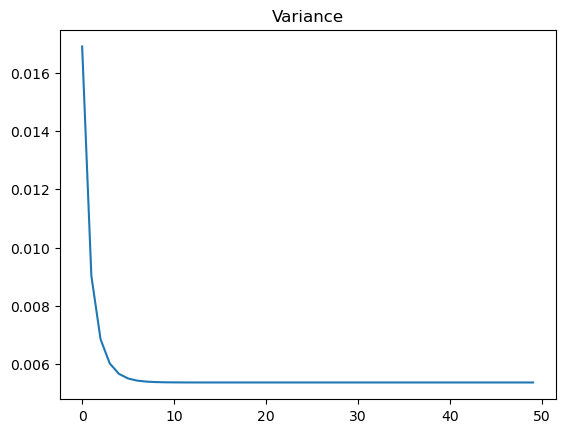

In [8]:
from numpy.random import randn
from collections import namedtuple
import numpy as np
import matplotlib.pyplot as plt

gaussian = namedtuple('Gaussian', ['mean', 'var'])
# カルマンフィルタ
#　観測値（シミュレータ）
def volt(voltage, std):
    return voltage + (randn() * std)

def update(prior, measurement):
    x, P = prior        # 事前分布の平均と分散
    z, R = measurement  # 観測値の平均と分散

    y = z - x        # 残差
    K = P / (P + R)  # カルマンゲイン

    x = x + K*y      # 事後分布の平均
    P = (1 - K) * P  # 事後分布の分散
    return gaussian(x, P)

def predict(posterior, movement):
    x, P = posterior # 事後分布の平均と分散
    dx, Q = movement # 移動量の平均と分散
    x = x + dx
    P = P + Q
    return gaussian(x, P)

temp_change = 0
voltage_std = .13
process_var = .05**2
actual_voltage = 16.3

x = gaussian(25., 1000.) # 初期状態 観測値を初期状態にすることもある
process_model = gaussian(0., process_var)

N = 50
zs = [volt(actual_voltage, voltage_std) for i in range(N)] # 観測値
ps = [] # 分散
estimates = [] # 推定値

for z in zs:
    prior = predict(x, process_model)
    x = update(prior, gaussian(z, voltage_std**2))

    # グラフにするために記録する
    estimates.append(x.mean)
    ps.append(x.var)

# フィルタの出力と分散をプロットする
plt.scatter(np.arange(N), zs)
plt.plot(np.arange(N), estimates)
plt.fill_between(np.arange(N), np.array(estimates)-np.array(ps), np.array(estimates)+np.array(ps))
plt.xlabel("step")
plt.ylabel("volts")
plt.show()

plt.plot(ps)
plt.title('Variance')
print('Variance converges to {:.3f}'.format(ps[-1]))

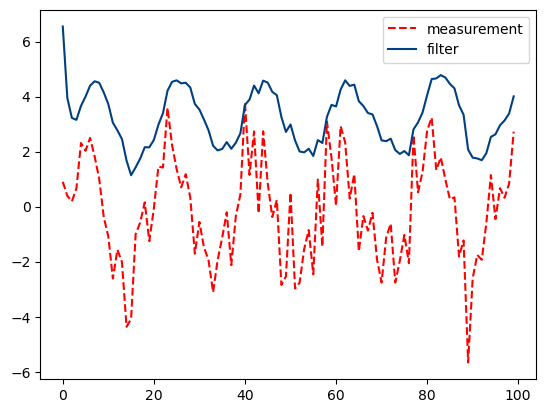

In [9]:
# 非線形な系からなる観測値（sin波など）で推定精度ガタ落ち
# 今までのカルマンは一次微分が一定（速度が一定）を仮定していたため
# 今回の問題では，一次微分が一定でない（加速が発生している、速度が変化している）ため推定値が最悪
import math

sensor_var = 30.
process_var = 2.
pos = gaussian(100., 500.)
process_model = gaussian(1., process_var)

zs, ps = [], []

for i in range(100):
    pos = predict(pos, process_model)

    z = math.sin(i/3.)*2 + randn()*1.2
    zs.append(z)

    pos = update(pos, gaussian(z, sensor_var))
    ps.append(pos.mean)

plt.plot(zs, c='r', linestyle='dashed', label='measurement')
plt.plot(ps, c='#004080', label='filter')
plt.legend(loc='best');

In [10]:
# kalman func
# predict(x, P, u, Q): x:系の状態, P:系の分散, u:プロセスの移動量, Q:プロセスのノイズ
# update(x, P, z, R): z:観測値, R:観測値の分散
import filterpy.kalman as kf

# N(10, 3) 移動量N(1, 4)
# kf.predict(x=10., P=3., u=1., Q=4.)


x, P = kf.predict(x=10., P=3., u=1., Q=2.**2)
print('%.3f' % x)

x, P = kf.update(x=x, P=P, z=12., R=3.5**2)
print('%.3f' % x, '%.3f' % P)

11.000
11.364 4.455


### 共分散：多変数間の相関を表現する指標
正の相関，負の相関，無相関（独立）
　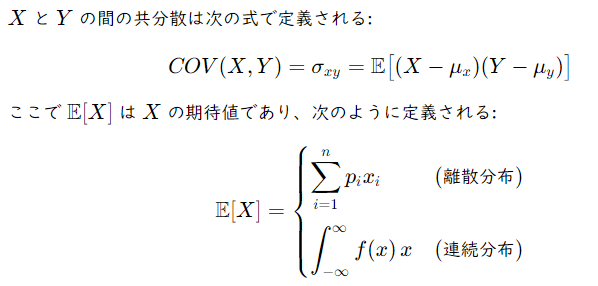
 
### 多変量正規分布
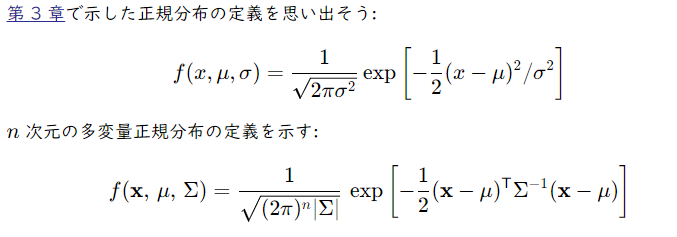

多変量ガウス分布の積
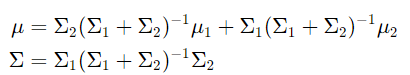
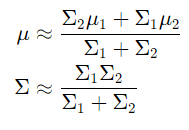

単変量
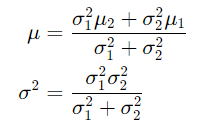

同時確率密度関数(joint probability density function) ：確率の密度（あくまで密度，積分して確率）<br>
同時確率(joint probability) P(x,y)： x と y の両方が起きる確率<br>
周辺確率 (marginal probability)：他の事象を考えに入れずに計算した特定の事象が起こる確率<br>

観測変数：位置のような観測する変数<br>
隠れ変数：観測変数から求まる速度のような変数<br>
観測不能変数：観測変数から求まらないエンジンの重量みたいな変数<br>

## 多変量カルマンフィルタ
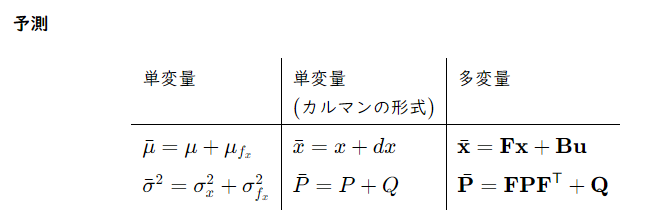
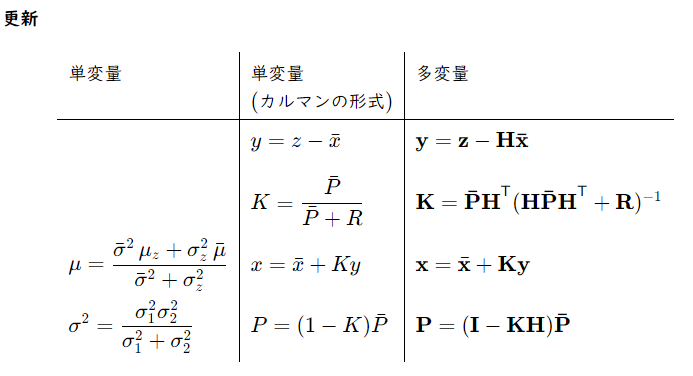

Ax=B 

In [11]:
from scipy.linalg import solve
A = np.array([[2, 3],[4, -1]])
b = np.array([[8], [2]])
x = solve(A, b)
x

array([[1.],
       [2.]])

[[0.99109429 0.54633196]
 [1.98372435 0.96940016]
 [2.99176802 0.99305602]
 [3.99568718 0.99844063]
 [4.99797689 1.00024258]]
[[1]
 [2]
 [3]
 [4]
 [5]]


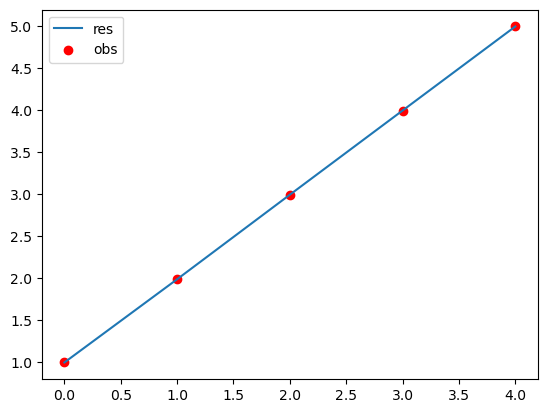

In [36]:
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def pos_vel_filter(x, P, R, Q=0., dt=1.0):
    """ 状態 [x dx].T に対する定常速度モデルを実装する KalmanFilter を返す。 """

    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([x[0], x[1]]) # 位置
    
    と速度
    kf.F = np.array([[1., dt],
                     [0.,  1.]])  # 状態遷移行列
    kf.H = np.array([[1., 0]])    # 観測関数
    kf.R *= R                     # 観測の不確実性
    if np.isscalar(P):
        kf.P *= P                 # 共分散行列
    else:
        kf.P[:] = P               # [:] を使ってディープコピーを行う。
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

def run(x0=(0.,0.), P=500, R=0, Q=0, dt=1.0,
        track=None, zs=None,
        count=0, do_plot=True, **kwargs):
    """ track は犬の実際の位置、zs は対応する観測値を表す。 """

    # データが与えられないなら犬のシミュレーションを実行する。
    if zs is None:
        track, zs = compute_dog_data(R, Q, count)

    # カルマンフィルタを作成する。
    kf = pos_vel_filter(x0, R=R, P=P, Q=Q, dt=dt)

    # カルマンフィルタを実行し、結果を保存する。
    xs, cov = [], []
    for z in zs:
        kf.predict()
        kf.update(z)
        xs.append(kf.x)
        cov.append(kf.P)

    xs, cov = np.array(xs), np.array(cov)
    return xs, cov

dt = 0.3
F = np.array([[1, dt], [0, 1]])
x = np.array([10.0, 4.5])
P = np.diag([500, 500])

Q = Q_discrete_white_noise(dim=2, dt=1., var=2.35)

kf = pos_vel_filter([0, .1], R=R, P=P, Q=Q, dt=1.)
s = Saver(kf)
for i in range(1, 6):
    kf.predict()
    kf.update([i])
    s.save()  # 現在状態を記録する
    
s.to_array()
print(s.x)
print(s.z)
plt.plot(np.arange(len(s.x[:, 0])), s.x[:, 0], label='res')
plt.scatter(np.arange(len(s.x[:, 0])), s.x[:, 0], label='obs', c='r')
plt.legend()
plt.show()

In [38]:
from scipy.linalg import inv
import math
import numpy as np
from numpy.random import randn

def compute_dog_data(z_var, process_var, count=1, dt=1.):
    """ 犬が通った点と観測値からなる一次元 ndarray を返す。 """
    x, vel = 0., 1.
    z_std = math.sqrt(z_var)
    p_std = math.sqrt(process_var)
    xs, zs = [], []
    for _ in range(count):
        v = vel + (randn() * p_std)
        x += v*dt
        xs.append(x)
        zs.append(x + randn() * z_std)
    return np.array(xs), np.array(zs)

dt = 1.
R_var = 10
Q_var = 0.01
x = np.array([[10.0, 4.5]]).T
P = np.diag([500, 49])
F = np.array([[1, dt],
              [0,  1]])
H = np.array([[1., 0.]])
R = np.array([[R_var]])
Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q_var)
count = 50
track, zs = compute_dog_data(R_var, Q_var, count)
xs, cov = [], []
for z in zs:
    # 予測
    x = F @ x
    P = F @ P @ F.T + Q

    # 更新
    S = H @ P @ H.T + R
    K = P @ H.T @ inv(S)
    y = z - H @ x
    x += K @ y
    P = P - K @ H @ P

    xs.append(x)
    cov.append(P)

xs, cov = np.array(xs), np.array(cov)